[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/decay_ideal_vortex.ipynb)


# LEARNING OBJECTIVE

This notebook illustrates the decay, caused by viscous friction in the flow, of an ideal vortex, using the "[Lamb&ndash;Oseen vortex](https://en.wikipedia.org/wiki/Lamb%E2%80%93Oseen_vortex)" solution of the incompressible Navier&ndash;Stokes equations.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np
from scipy.optimize import fsolve

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# AN IDEAL VORTEX

An ideal vortex has the velocity field, in cylindrical coordinates:
$$
    v_r = 0,\qquad v_\theta = v_\theta(r) = \frac{\Gamma}{2\pi r},\qquad v_z =0.
$$

We can check that this is indeed an _ideal_ flow solution by verifying that the flow is _incompressible_, $\nabla\cdot\underline{v}=0$, and _irrotational_, $\omega = \nabla \times \underline{v}=\underline{0}$ (thus, also _inviscid_, since for a Newtonian fluid $\nabla\cdot\underline{\underline{\tau}} = -\mu \nabla\times\underline{\omega} = \underline{0}$ if $\underline{\omega} = \underline{0}$.)

We can do our checks using SymPy's [`vector`](https://docs.sympy.org/latest/modules/vector/index.html) module:

In [2]:
# create a cylindrical coordinate system for us to define vectors in
c = CoordSys3D('c')
cp = c.create_new('cp', transformation='cylindrical',
                  vector_names=("r", "th", "z"),
                  variable_names=("R", "Th", "Z"))

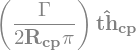

In [3]:
# the ideal vortex' velocity
Gamma = sp.symbols('Gamma')
v = Gamma/(2*sp.pi*cp.R) * cp.th
display(v)

In [4]:
# divergence of v
divergence(v)

In [5]:
# curl of v
curl(v)

# DECAY OF AN IDEAL VORTEX

## Self-similar solution

Lamb&ndash;Oseen vortex solution takes the ideal vortex as an initial condition and allows it to decay due to viscous friction in the flow, generated by "plugging the drain" of a vortex tank (check out the demo in [NCFMF film "Vorticity Part 1"](https://techtv.mit.edu/collections/ifluids/videos/32614-vorticity-part-1)!), that is represented by the BC $v_\theta(r=0,t>0)=0$. 

Specifically, initial-boundary-value-problem (IBVP) is 
\begin{align*}
    \frac{\partial v_\theta}{\partial t} &= \nu \frac{\partial}{\partial r}\left[\frac{1}{r}\frac{\partial}{\partial r}\left(r v_\theta\right)\right],\\
    v_\theta(r, t = 0) &= \frac{\Gamma}{2\pi r},\\
    v_\theta(r \to \infty, t \ge 0) &\sim \frac{\Gamma}{2\pi r},\\
    v_\theta(r = 0, t > 0) &= 0,
\end{align*}
according to Panton, Sec. 11.8.

A self-similar solution is possible, letting $v_\theta(r,t) = \frac{\Gamma}{2\pi r}f(\eta)$ with $\eta = r/\sqrt{\nu t}$. Then, the IBVP becomes
\begin{align*}
    f'' + \left(\frac{\eta}{2}-\frac{1}{\eta}\right)f' &=0,\\
    f(\eta\to \infty) &= 1,\\
    f(\eta\to 0) &= 0.
\end{align*}

The self-similar solution is easily found to be
$$
    f(\eta) = 1 - \exp\left(-\frac{\eta^2}{4}\right).
$$
Thus,
$$
    v_\theta(r,t) = \frac{\Gamma}{2\pi r}\left[1 - \exp\left(-\frac{r^2}{4\nu t}\right)\right]
$$

In [6]:
# define the self-similar solution as a function
def f_selfsimilar(eta):
    return 1 - np.exp(-eta**2/4)

The vorticity vector $\underline{\omega}$ is oriented in the $z$-direction:
$$
    \omega_r = \omega_\theta = 0, \qquad \omega_z = \frac{1}{r}\frac{\partial}{\partial r}(r v_\theta) = \frac{\Gamma}{4\pi \nu t} \exp\left(-\frac{r^2}{4\nu t}\right).
$$

If you didn't remember how to compute $\underline{\omega} = \nabla\times\underline{v}$ in cylindrical coordinates, SymPy can help:

In [7]:
v_theta = sp.Function('v_theta')(cp.R)
flow_field = v_theta*cp.th
display(flow_field)

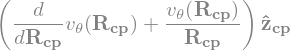

In [8]:
curl(flow_field).simplify()

Clearly, the vorticity vector $\underline{\omega}$ of this flow has only 1 component, in the $\underline{e}_z$ direction (this unit normal is denoted as $\mathbf{\hat{z}_\mathrm{\mathbf{cp}}}$ by SymPy).

## Visualization

### Azimuthal velocity

In [ ]:
# kinematic viscosity of water
nu = 1  # mm^2/s, so time will be in s and distance in mm for the plots below

# circulation
Gm = 1  # also in mm^2/s

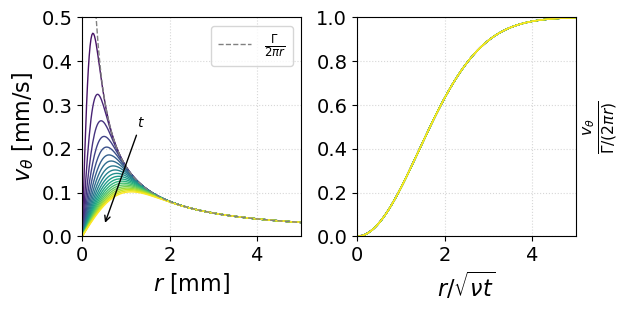

In [10]:
# define vertical extent of the eta plot and grid
etamax = 5.0
eta = np.linspace(0, etamax, 250)

# define vertical extent of the r plot and grid (avoiding r=0 singularity)
rmax = 5.0
r = np.linspace(1e-6, rmax, 250)

# sequential colormap with gradient that looks nice, also try 'cool' or 'summer'
# https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential
cmap = colormaps['viridis']

# set up the figure and axis
fig, ax = plt.subplots(1, 2, tight_layout=True)
ax[0].set_xlabel('$r$ [mm]')
ax[0].set_xlim(0, rmax)
ax[0].set_ylabel(r'$v_\theta$ [mm/s]')
ax[0].set_ylim(0, 0.5)
ax[0].set_aspect(1.0/ax[0].get_data_ratio(), adjustable='box')

ax[1].set_xlabel(r'$r/\sqrt{\nu t}$')
ax[1].set_xlim(0, etamax)
ax[1].set_ylabel(r'$\frac{v_\theta}{\Gamma/(2\pi r)}$')
ax[1].set_ylim(0, 1)
ax[1].set_aspect(1.0/ax[1].get_data_ratio(), adjustable='box')
ax[1].yaxis.set_label_position('right')

tmin = 0.012
tmax = 0.25
for t in np.linspace(tmin, tmax, 20):
    vth = Gm/(2*np.pi*r)*f_selfsimilar(r/np.sqrt(nu*t))
    tcol = cmap(t/tmax)  # argument from 0 to 1
    ax[0].plot(r, vth, linewidth=1, color=tcol)
    ax[1].plot(r/np.sqrt(nu*t), vth/(Gm/(2*np.pi*r)), linewidth=1, color=tcol)

ax[0].plot(r, Gm/(2*np.pi*r), color='gray', linewidth=1, linestyle='dashed',
           label=r'$\frac{\Gamma}{2\pi r}$')
ax[0].legend()

ax[1].grid(alpha=0.5, linestyle='dotted')
ax[0].grid(alpha=0.5, linestyle='dotted')

ax[0].annotate('$t$', xy=(0.5, 0.025), xytext=(1.25, 0.25), 
               arrowprops=dict(arrowstyle="->"));

We can also illustrate the solution as an animation.

In [ ]:
# define vertical extent of the eta plot and grid
etamax = 5.0
eta = np.linspace(0, etamax, 500)

# define vertical extent of the r plot and grid (avoiding r=0 singularity)
rmax = 5.0
r = np.linspace(1e-6, rmax, 500)

# sequential colormap with gradient that looks nice, also try 'cool' or 'summer'
# https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential
cmap = colormaps['viridis']

# set up the figure and axis
fig, ax = plt.subplots(1, 2, tight_layout=True)
ax[0].set_xlabel('$r$ [mm]')
ax[0].set_xlim(0, rmax)
ax[0].set_ylabel(r'$v_\theta$ [mm/s]')
ax[0].set_ylim(0, 0.3)
ax[0].set_aspect(1.0/ax[0].get_data_ratio(), adjustable='box')

ax[1].set_xlabel(r'$r/\sqrt{\nu t}$')
ax[1].set_xlim(0, etamax)
ax[1].set_ylabel(r'$\frac{v_\theta}{\Gamma/(2\pi r)}$')
ax[1].set_ylim(0, 1)
ax[1].set_aspect(1.0/ax[1].get_data_ratio(), adjustable='box')
ax[1].yaxis.set_label_position('right')

ax[1].grid(alpha=0.5, linestyle='dotted')
ax[0].grid(alpha=0.5, linestyle='dotted')
plt.close()

# initialize plot and quiver objects with some dummy data (replaced in animation)
ax[0].plot(r, 0*r, linewidth=1, color=cmap(0))
ax[1].plot(eta, 0*eta, linewidth=1, color=cmap(0))

# add envelope of all curves
ax[0].plot(r, Gm/(2*np.pi*r), 
           color='gray', linewidth=1, linestyle='dashed',
           label=r'$\frac{\Gamma}{2\pi r}$')
ax[0].legend()

time_label = ax[0].annotate('$t=0$', xy=(0.675*rmax, 0.45))

# number of animation frames
numframes = 50
tmin = 0.05
tmax = 0.3

# animation function called sequentially by 'FuncAnimation' below
def animate(t):
    # the t passed is actually the frame counter, not time
    # so it should be rescaled to get actual time as % of the frames
    # also shift it slightly so we don't divide by 0
    tt = tmin + t/numframes * tmax

    vth = Gm/(2*np.pi*r)*f_selfsimilar(r/np.sqrt(nu*tt))
    randcol = cmap(tt/tmax)  # argument from 0 to 1
    ax[0].plot(r, vth, linewidth=1, color=randcol)
    ax[1].plot(r/np.sqrt(nu*tt), vth/(Gm/(2*np.pi*r)),
               linewidth=1, color=randcol)

    # dynamic time label in the corner
    time_label.set_text(f'$t={tt:.2f}$ s')

    return fig,


anim = animation.FuncAnimation(fig, animate,
                               frames=numframes, interval=300, blit=True, repeat=False)

In [12]:
# this is necessary to get the animation to work on Google's Colab
rc('animation', html='jshtml')
display(anim)

In [13]:
# To save the animation, use e.g.
# ani.save(f"vortex_vel_movie.mp4")

# or
# writer = animation.FFMpegWriter(fps=15, metadata=dict(artist='Me'), bitrate=1800)
# ani.save(f"vortex_vel_movie.mp4", writer=writer)

### Vorticity

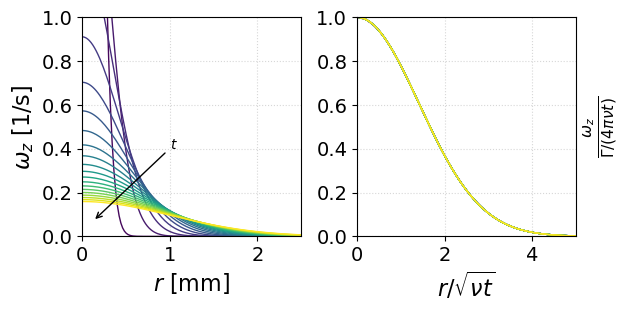

In [14]:
# define vertical extent of the eta plot and grid
etamax = 5.0
eta = np.linspace(0, etamax, 250)

# define vertical extent of the t plot and grid
rmax = 5.0
r = np.linspace(0, rmax, 250)

# set up the figure and axis
fig, ax = plt.subplots(1, 2, tight_layout=True)
ax[0].set_xlabel('$r$ [mm]')
ax[0].set_xlim(0, rmax/2)
ax[0].set_ylabel(r'$\omega_z$ [1/s]')
ax[0].set_ylim(0, 1)
ax[0].set_aspect(1.0/ax[0].get_data_ratio(), adjustable='box')

ax[1].set_xlabel(r'$r/\sqrt{\nu t}$')
ax[1].set_xlim(0, etamax)
ax[1].set_ylabel(r'$\frac{\omega_z}{\Gamma/(4\pi \nu t)}$')
ax[1].set_ylim(0, 1)
ax[1].set_aspect(1.0/ax[1].get_data_ratio(), adjustable='box')
ax[1].yaxis.set_label_position('right')

tmin = 0.01
tmax = 0.5
for t in np.linspace(tmin, tmax, 20):
    wz = Gm/(4*np.pi*nu*t)*np.exp(-r**2/(4*nu*t))
    tcol = cmap(t/tmax)  # argument from 0 to 1
    ax[0].plot(r, wz, linewidth=1, color=tcol)
    ax[1].plot(r/np.sqrt(nu*t), wz/(Gm/(4*np.pi*nu*t)),
               linewidth=1, color=tcol)

ax[1].grid(alpha=0.5, linestyle='dotted')
ax[0].grid(alpha=0.5, linestyle='dotted')

ax[0].annotate('$t$', xy=(0.125, 0.07), 
               xytext=(1.0, 0.4), arrowprops=dict(arrowstyle="->"));

### Vector field

In [15]:
# range
xmax = 3
ymax = 3

# grid, picking an even num to avoid (0,0) being in the plotting points
# obviously, "bad things" happen at the origin when we go to polar coords
x, y = np.meshgrid(np.linspace(-xmax, xmax, num=36),
                   np.linspace(-ymax, ymax, num=36))

# convert (x,y) to (r,th) for plotting in polar coordinates
# note: arctan2(y,x) computes arctangent(y/x) taking into account the
# signs of x and y, which is important for these problems.
# if you use atan(y/x), you'd get funny results due to the 'branch cut' of atan.
r = np.sqrt(x**2 + y**2)
th = np.arctan2(y, x)

In [16]:
# set up the figure and axis
fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel('$y$ [mm]')
ax.set_xlabel('$x$ [mm]')
ax.set_aspect('equal')

# initialize plot and quiver objects with the ideal vortex solution

# the polar velocity field
vr = 0*r
vth = Gm/(2*np.pi*r)

# transform polar velocities to Cartesian ones for plotting
vx = vr*np.cos(th) - vth*np.sin(th)
vy = vr*np.sin(th) + vth*np.cos(th)

# skip every other data point to reduce number of arrows
quiv = ax.quiver(x[::2], y[::2], vx[::2], vy[::2],
                 scale=0.3, scale_units='xy', color='blue')


# if you want to save the thumbnail to a file
# fig.savefig(f"vortex_quiver_thumb.pdf") # bbox_inches='tight'

plt.close()

# number of animation frames
numframes = 50
tmax = 1

time_label = ax.annotate('$t=0$', xy=(0.8*xmax, 0.9*ymax),
                         bbox=dict(boxstyle="round", facecolor="white"))

# animation function called sequentially by `FuncAnimation' below
def animate(t):
    # the t passed is actually the frame counter, not time
    # so it should be rescaled to get actual time as % of the frames
    # also shift it slightly so we don't divide by 0
    tt = tmin + t/numframes * tmax

    # the polar velocity field
    vr = 0*r
    vth = Gm/(2*np.pi*r)*f_selfsimilar(r/np.sqrt(nu*tt))

    # transform polar velocities to Cartesian ones for plotting
    vx = vr*np.cos(th) - vth*np.sin(th)
    vy = vr*np.sin(th) + vth*np.cos(th)

    # plot arrows emanating only from the reference line, x-coord = 0
    quiv.set_UVC(vx[::2], vy[::2])

    # dynamic time label in the corner
    time_label.set_text(f'$t={tt:.2f}$ s')

    return (quiv,)


anim = animation.FuncAnimation(fig, animate,
                               frames=numframes, interval=500, blit=True)

In [17]:
# this is necessary to get the animation to work on Google's Colab
rc('animation', html='jshtml')
anim

In [18]:
# To save the animation, use e.g.
# ani.save(f"vortex_quiver_movie.mp4")

# or
# writer = animation.FFMpegWriter(fps=15, metadata=dict(artist='Me'), bitrate=1800)
# ani.save(f"vortex_quiver_movie.mp4", writer=writer)